In [1]:
import os
import sys
import anndata as ad
import numpy as np

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
import itertools
import metacells as mc

f_dir = os.path.dirname(os.path.abspath("__file__"))  
sys.path.append(os.path.abspath(os.path.join(f_dir, "..", "..", "utils")))

import constants
import utils

from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact, chi2_contingency
import itertools
from itertools import combinations


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

2026-04-20 11:36:53.243448: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 11:36:53.265407: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.makedirs("./output", exist_ok=True)

In [3]:
def get_clones_info(current_bemp_clones):
    only_eosi_clones = current_bemp_clones.index[(current_bemp_clones.Eosinophil > 0) & (current_bemp_clones.Mast == 0) & (current_bemp_clones.Basophils == 0)]
    only_mast_clones = current_bemp_clones.index[(current_bemp_clones.Mast > 0) & (current_bemp_clones.Eosinophil == 0) & (current_bemp_clones.Basophils == 0)]
    only_basophils_clones = current_bemp_clones.index[(current_bemp_clones.Basophils > 0) & (current_bemp_clones.Eosinophil == 0) & (current_bemp_clones.Mast == 0)]

    eosi_mast_clones = current_bemp_clones.index[(current_bemp_clones.Eosinophil > 0) & (current_bemp_clones.Mast > 0) & (current_bemp_clones.Basophils == 0)]
    eosi_baso_clones = current_bemp_clones.index[(current_bemp_clones.Eosinophil > 0) & (current_bemp_clones.Basophils > 0) & (current_bemp_clones.Mast == 0)]
    mast_baso_clones = current_bemp_clones.index[(current_bemp_clones.Mast > 0) & (current_bemp_clones.Basophils > 0) & (current_bemp_clones.Eosinophil == 0)]
    all_three_clones = current_bemp_clones.index[(current_bemp_clones.Eosinophil > 0) & (current_bemp_clones.Basophils > 0) & (current_bemp_clones.Mast > 0)]

    return {
        "Eosinophil": only_eosi_clones,
        "Basophils": only_basophils_clones,
        "Mast": only_mast_clones,
        "Eosinophil_Basophils": eosi_baso_clones,
        "Mast_Basophils": mast_baso_clones,
        "Eosinophil_Mast": eosi_mast_clones,
        "Eosinophil_Mast_Basophils": all_three_clones,
    }, len(current_bemp_clones)
    

def get_clones_info_automatic(current_bemp_clones):
    """
    Groups clone indices based on all combinations of specified columns having a value > 0,
    while all other specified columns have a value of 0.

    Args:
        current_bemp_clones (pd.DataFrame): DataFrame containing clone data.
        column_names (list): List of column names (cell types) to consider for combinations.

    Returns:
        tuple: A dictionary containing clone indices for each combination and the total number of clones.
    """
    column_names = current_bemp_clones.columns.tolist()
    results = {}

    # Iterate through combinations of length 1 up to the total number of columns
    for r in range(1, len(column_names) + 1):
        for combo in combinations(column_names, r):
            # 1. Columns that MUST be > 0 (the "positive" columns)
            positive_cols = list(combo)
            
            # 2. Columns that MUST be == 0 (the "negative" columns)
            negative_cols = [col for col in column_names if col not in positive_cols]

            # Initialize the boolean mask to True
            mask = pd.Series(True, index=current_bemp_clones.index)

            # Apply the positive conditions: column > 0
            for col in positive_cols:
                mask &= (current_bemp_clones[col] > 0)
            
            # Apply the negative conditions: column == 0
            # This ensures we get *ONLY* the combination of the positive_cols
            for col in negative_cols:
                mask &= (current_bemp_clones[col] == 0)

            # Get the indices that satisfy the combined mask
            clone_indices = current_bemp_clones.index[mask]
            
            # Create a descriptive key for the result dictionary
            key = "_".join(positive_cols)
            
            # Store the result
            results[key] = clone_indices

    return results, len(current_bemp_clones)
    
    
def plot_cells_distribution(clones_info_dict, cells_with_clones, types, cell_type_colors, output_folder = None, filename_prefix = ""):
    for key in clones_info_dict:
        
        cells_to_look_at = cells_with_clones[cells_with_clones.obs.top_level_cell_type.isin(types)]
        cells_per_clone = cells_to_look_at[cells_to_look_at.obs.clone_exp_id.isin(clones_info_dict[key])].obs.groupby(["sample_day_bin","clone_exp_id","top_level_cell_type"],observed=True).size().unstack(fill_value=0)
        cells_per_clone_types = cells_to_look_at[cells_to_look_at.obs.clone_exp_id.isin(clones_info_dict[key])].obs.groupby(["sample_day_bin","clone_exp_id","cell_type"],observed=True).size().unstack(fill_value=0)
        if "Mast" in cells_per_clone_types.columns:
            cells_per_clone["Mast"] = cells_per_clone_types.Mast
        if "MastP" in cells_per_clone_types.columns:
            cells_per_clone["MastP"] = cells_per_clone_types.MastP
        cells_distribution_per_clone = cells_per_clone.div(cells_per_clone.sum(axis=1), axis=0)
        total_distribution = cells_distribution_per_clone.groupby("sample_day_bin", observed=False).mean()
        if total_distribution.sum().sum() == 0:
            continue
        
        for i in ["Early", "Mid", "Late"]:
            if i not in total_distribution.index:
                total_distribution.loc[i] = 0.0

        total_distribution = total_distribution.loc[["Early", "Mid", "Late"]]
        total_distribution = total_distribution * 100
        
        types_order = [i for i in types if i in total_distribution.columns]
        total_distribution = total_distribution[types_order]
        
        print(key)
        total_distribution.plot(kind="bar", figsize=(1.5,2), color=[cell_type_colors[i] for i in total_distribution.columns], stacked=True, width=0.9)
        plt.legend().remove()
        plt.ylabel("Cell state (%)", fontsize=17)
        plt.xlabel("Time bin", fontsize=17)
        plt.yticks(range(0,101,20), fontsize=17)
        plt.ylim(0,100)
        
        if output_folder:
            plt.savefig(os.path.join(output_folder, "%s_%s.pdf" % (filename_prefix, key)), dpi=300, bbox_inches='tight')
            
        plt.show()
        
        
def rna_fraction_formatter(v, pos):
    if not float(v).is_integer():
        return ""
    return rf"$2^{{{int(v)}}}$"

In [4]:
output_path = os.path.join(f_dir, "output")
os.makedirs(output_path, exist_ok=True)

In [5]:
output_path = os.path.join(f_dir, "output")
os.makedirs(output_path, exist_ok=True)


cells_ad = ad.read_h5ad(constants.CELLS_PATH)
metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

cells_ad = mc.ut.slice(cells_ad, obs=~cells_ad.obs.cell_type.isin(["doublets", "Outliers"]))
cells_ad = mc.ut.slice(cells_ad, obs=cells_ad.obs.clone_id.notna())


cells_with_clones_info = mc.ut.slice(cells_ad, obs = ~cells_ad.obs.clone_id.isin(["nan", "unknown", "doublets"]))
cells_with_clones_info = mc.ut.slice(cells_with_clones_info, obs=cells_with_clones_info.obs.clone_id.notna())

clone_counts = cells_with_clones_info.obs['clone_exp_id'].value_counts()
valid_clone_ids = clone_counts[clone_counts > 1].index

cells_with_clones = cells_with_clones_info[cells_with_clones_info.obs['clone_exp_id'].isin(valid_clone_ids)]

In [6]:
cells_ad.obs.condition.value_counts()

condition
I          21656
unknown    14412
III         9810
II          3597
IV          2566
V           1383
VI           647
VII          146
Name: count, dtype: int64

In [7]:
bemp_trajectory_metacells = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.top_level_cell_type.isin(["Mast","Basophils","Eosinophil","BEP","BEMP","MEBEMP"]))
bemp_trajectory_lgc = utils.get_lgc(bemp_trajectory_metacells)
bemp_trajectory_rlgc = bemp_trajectory_lgc.sub(bemp_trajectory_lgc.median(axis=0),axis=1)

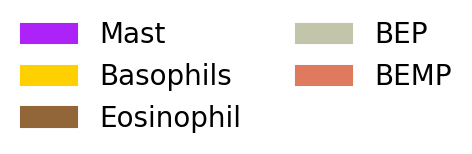

In [8]:
utils.plot_generic_dict_of_colors({i: cell_type_colors[i] for i in ["Mast","Basophils","Eosinophil","BEP","BEMP"]}, ncol=2, output_path=os.path.join("./output", "5A_legend.pdf"))
utils.plot_generic_dict_of_colors({i: cell_type_colors[i] for i in ["Mast","Basophils","Eosinophil","BEP","BEMP"]}, ncol=2)

## Figure 5A & S5C

In [8]:
fontsize = 35

heatmap_markers = [
    'FABP5','HLA-DRA','TUBA1B',
    'ARHGAP18','CD44','HPGDS','KIT','TPSAB1', 'TPSB2',
    'AKAP12', 'ALOX5', 'CEBPA', 'CSF2RB', 'RUNX1', 'SLC45A3',
    'EBP', 'ENTPD7', 'EPX', 'PRG3', 'RNASE3',
    'SRPRB', 'IGLL1', 'FKBP11', 'LMAN1','TXNDC5', 'LRRC59', 'SSR1', 'MLEC', 'TM7SF3', 'SEC61A1', 'MYDGF',
    "LYZ", "ELANE","MPO",
    ]

tf_list = ["GATA1","GATA2","KLF1","TAL1","LMO2","LMO4","MYB","MYC","MAX","SPI1","CEBPA","CEBPB","CEBPE","RUNX1","RUNX2","RUNX3","IKZF2","IKZF1","ETS1","ETS2",
           "ELK4","PDLIM1","ID2","PBX1","MEF2C","BCL11A","NFIA",]

bemp_mc = bemp_trajectory_metacells.obs_names[bemp_trajectory_metacells.obs.type == "BEMP"]
mast_mc = bemp_trajectory_metacells.obs[bemp_trajectory_metacells.obs.top_level_cell_type == "Mast"].Mast_pseudotime.sort_values().index 
baso_mc = bemp_trajectory_metacells.obs[bemp_trajectory_metacells.obs.type == "Basophils"].Basophils_pseudotime.sort_values(ascending=False).index # sorted by mast_gm_score
eosi_mc = bemp_trajectory_metacells.obs[bemp_trajectory_metacells.obs.type == "Eosinophil"].Eosinophil_pseudotime.sort_values(ascending=False).index
bep_mc = bemp_trajectory_metacells.obs[bemp_trajectory_metacells.obs.type == "BEP"].Eosinophil_pseudotime.sort_values().index

mc_order = bemp_mc.to_list() + mast_mc.to_list() + baso_mc.to_list() + eosi_mc.to_list() + bep_mc.to_list()
col_colors = metacells_ad[mc_order].obs.top_level_cell_type.map(cell_type_colors)
col_colors.name = "State"

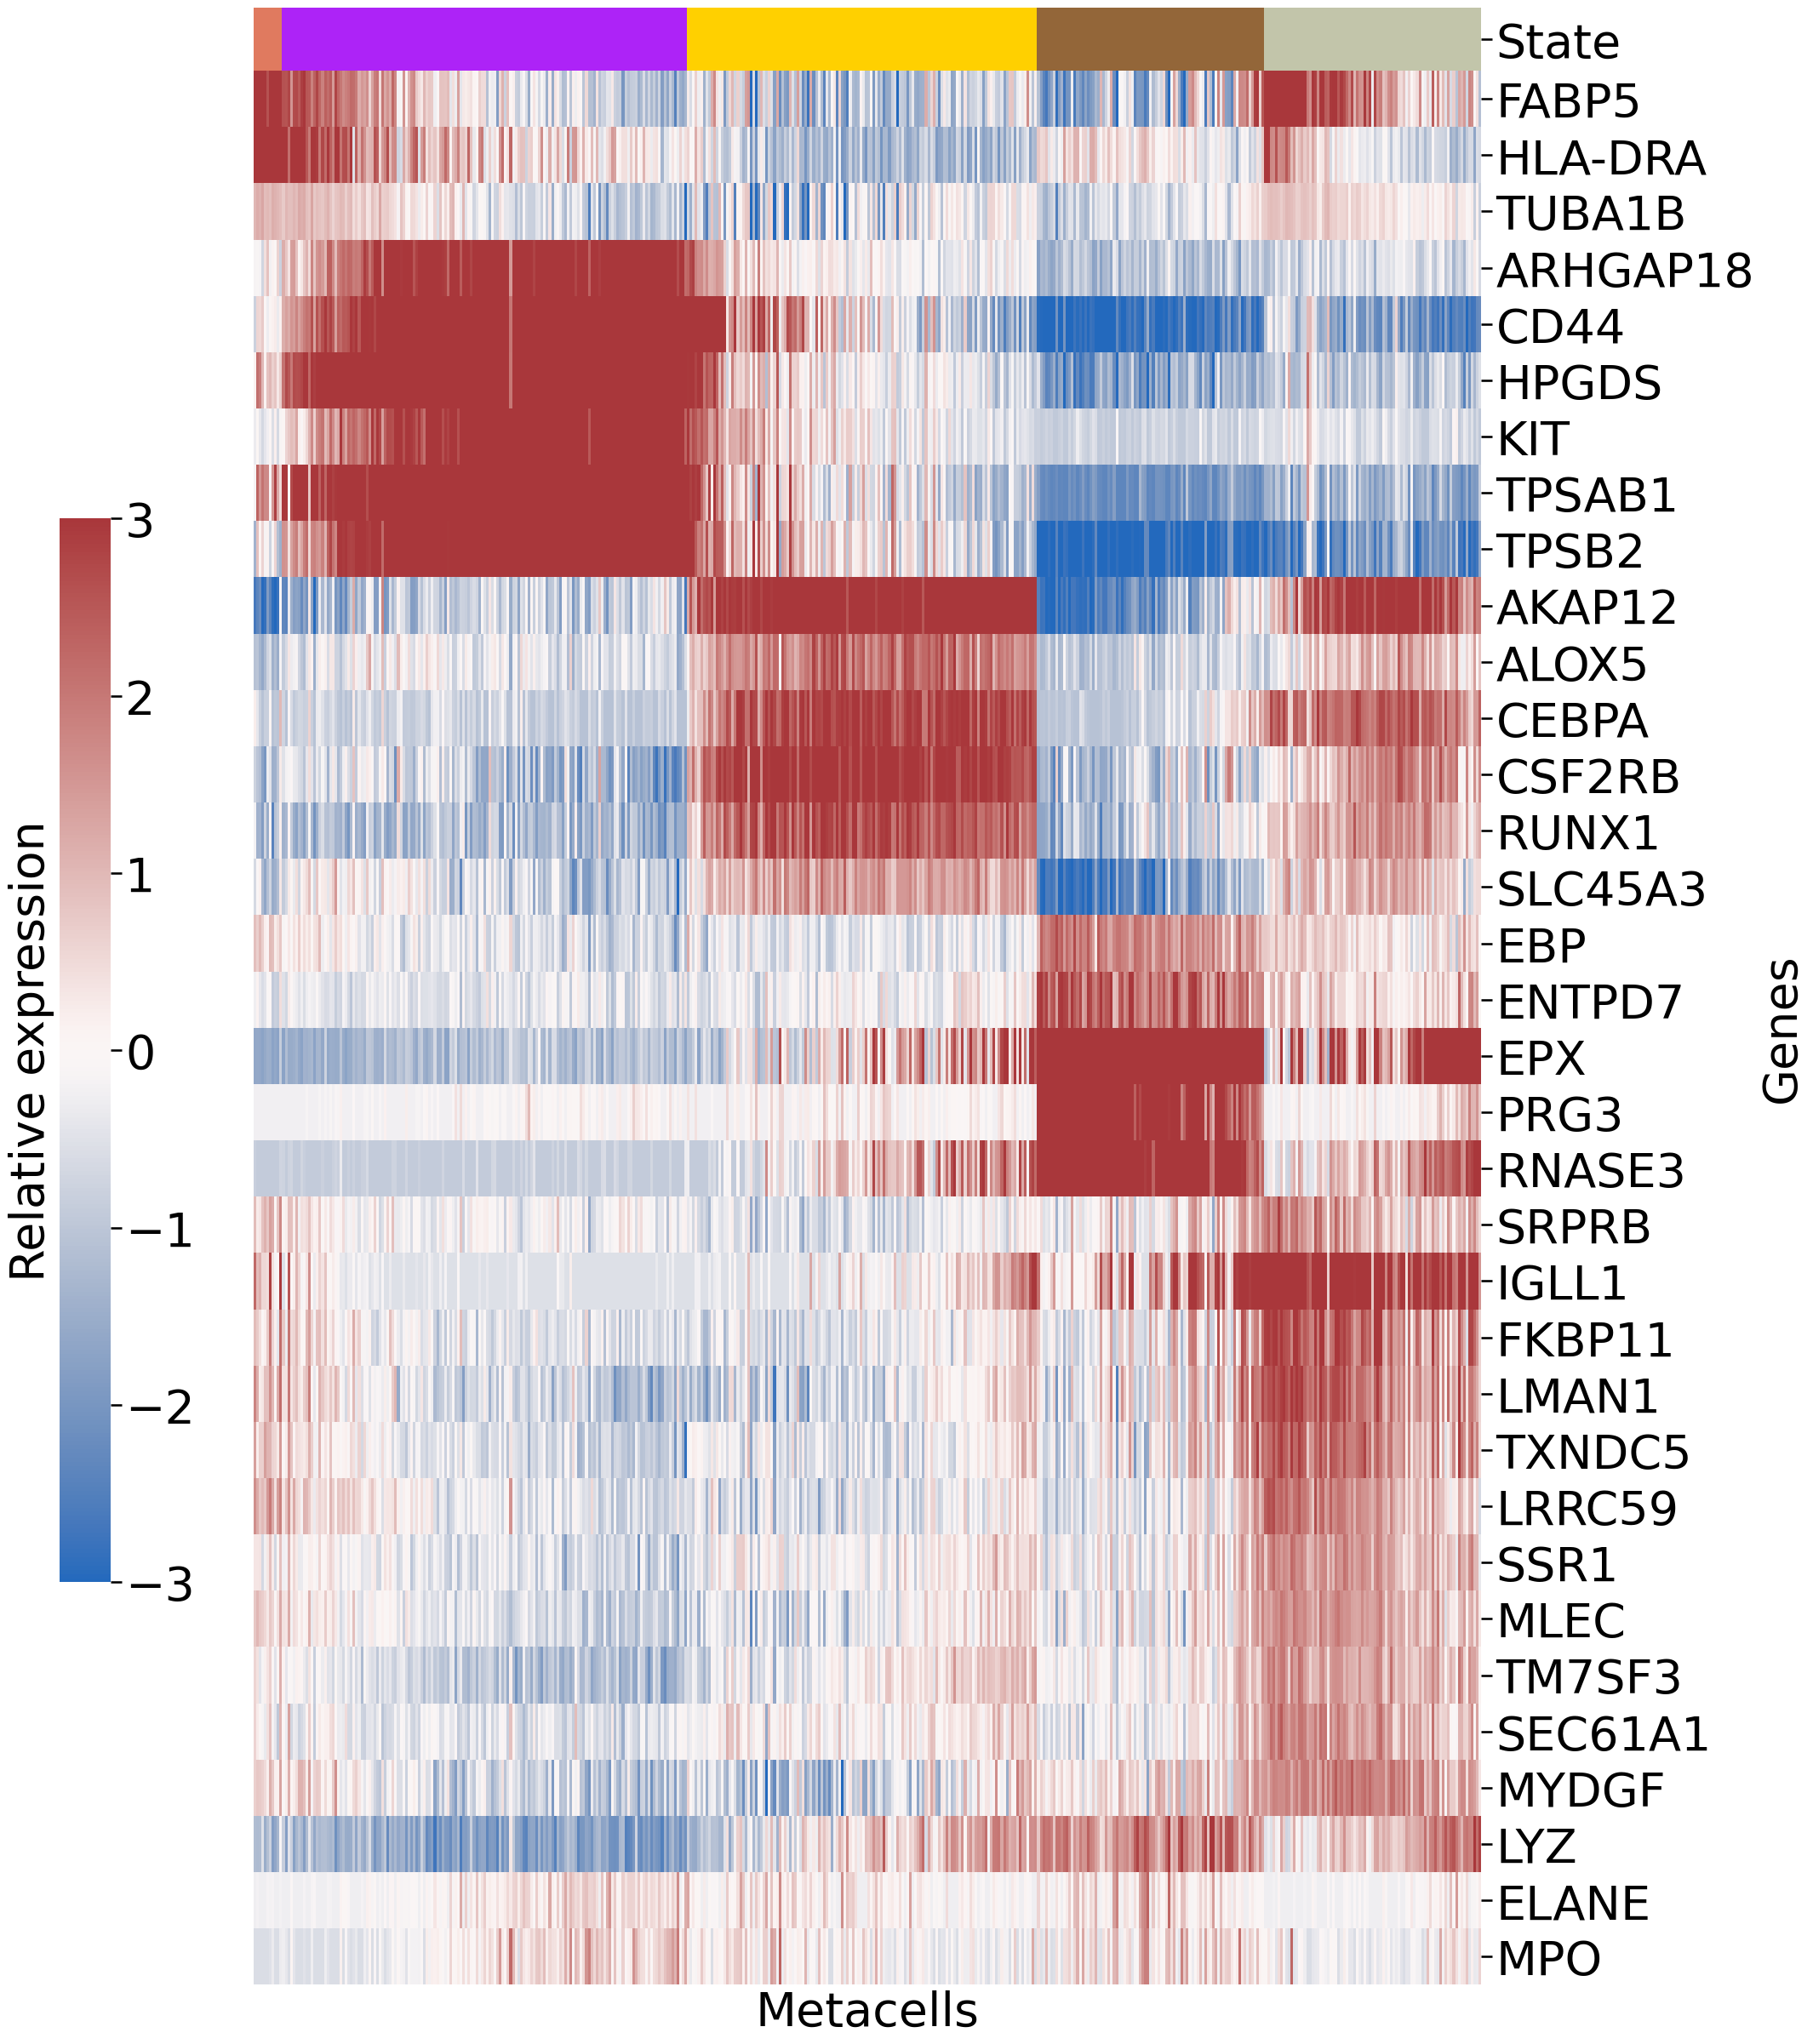

In [44]:
fontsize = 40
bemp_trajectory_rlgc_bemp_genes = bemp_trajectory_rlgc.loc[mc_order,heatmap_markers]
g = sb.clustermap(bemp_trajectory_rlgc_bemp_genes.T, cmap="vlag", center=0, mask=bemp_trajectory_rlgc_bemp_genes.T==0, vmin=-3, vmax=3, figsize=(20,25),
                        xticklabels=False, cbar_pos=(0.08, 0.2, 0.03, 0.5), col_cluster=False, row_cluster=False,
                        col_colors=col_colors, 
                        dendrogram_ratio=(.2, .05), )



ax_col_colors = g.ax_col_colors
box = ax_col_colors.get_position()

# # remove dendogrem lines
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Update tick font sizes
for ax in [g.ax_heatmap, g.ax_col_colors, g.ax_row_colors]:
    if ax is not None:
        ax.tick_params(labelsize=fontsize)

# Colorbar ticks
if g.cax is not None:
    g.cax.set_ylabel("Relative expression", fontsize=fontsize, rotation=90)
    g.cax.yaxis.set_label_position("left")
    g.cax.tick_params(labelsize=fontsize)


# Axis labels 
g.ax_heatmap.set_xlabel("Metacells", fontsize=fontsize)
g.ax_heatmap.set_ylabel("Genes", fontsize=fontsize)
g.savefig(os.path.join(output_path, "bemp_trajectory_heatmap.pdf"))
plt.show()

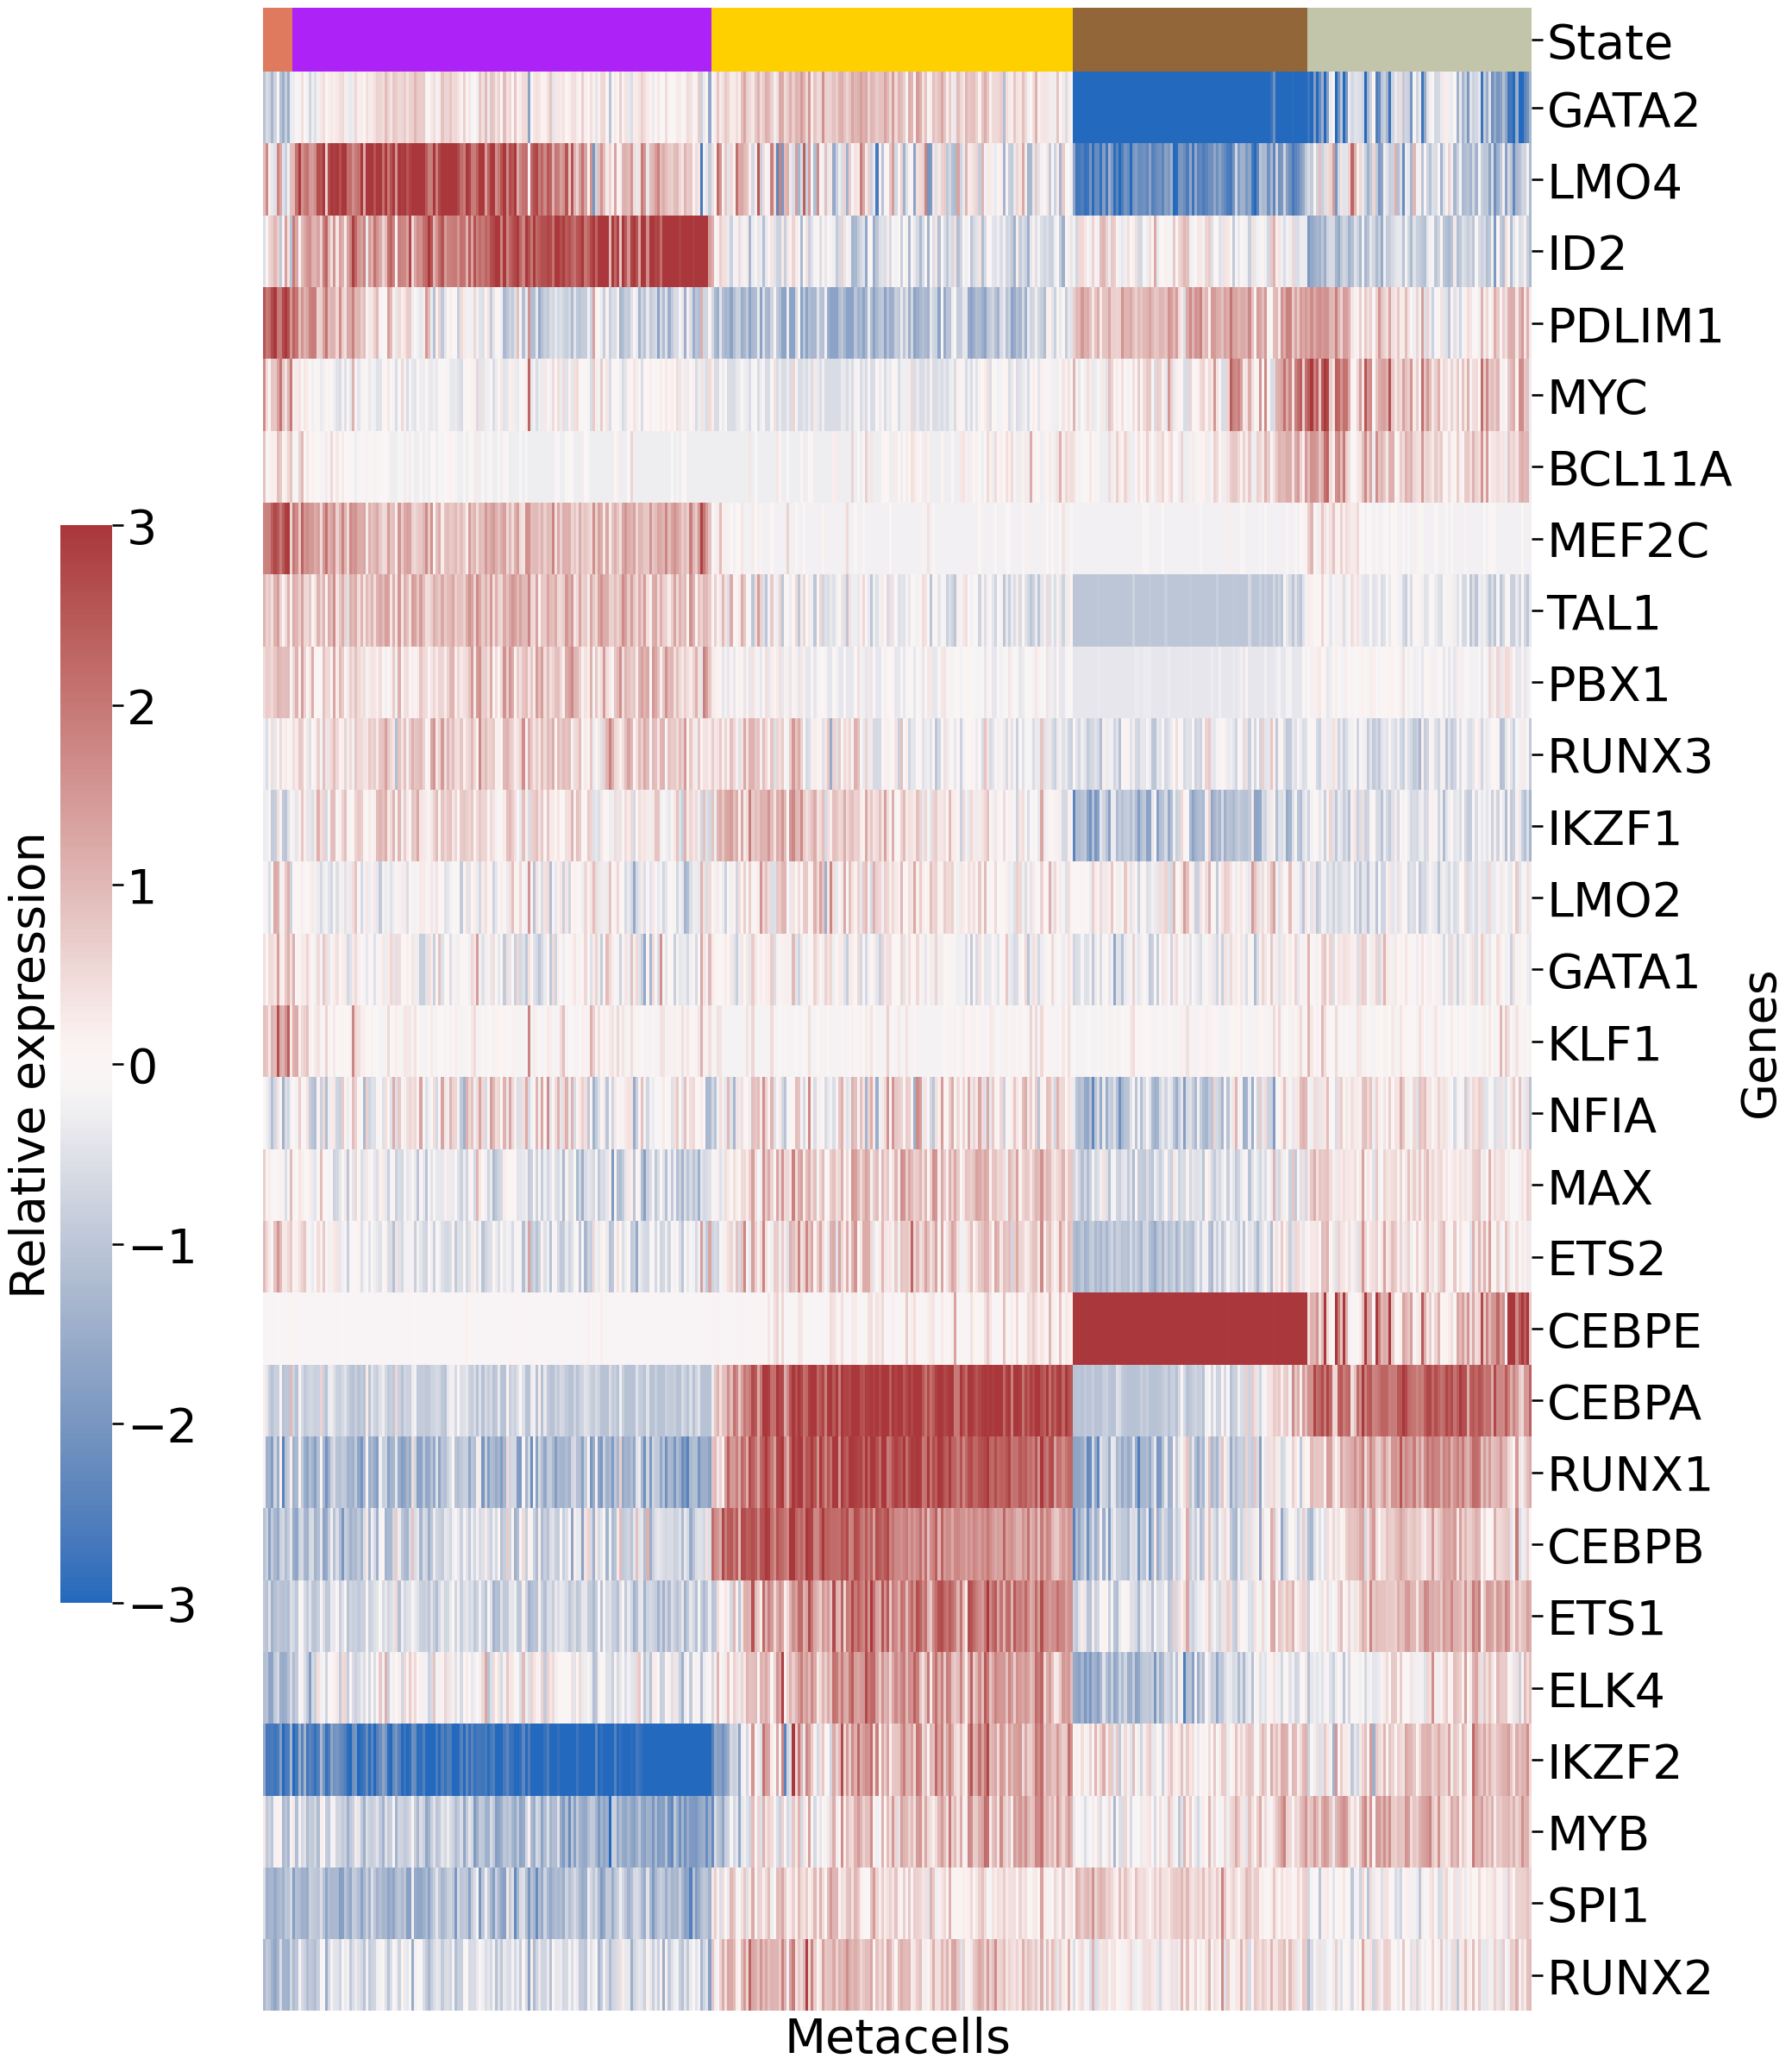

In [46]:
bemp_trajectory_rlgc_bemp_genes = bemp_trajectory_rlgc.loc[mc_order,tf_list]
g = sb.clustermap(bemp_trajectory_rlgc_bemp_genes.T, cmap="vlag", center=0, mask=bemp_trajectory_rlgc_bemp_genes.T==0, vmin=-3, vmax=3, figsize=(20,25),
                        xticklabels=False, cbar_pos=(0.08, 0.2, 0.03, 0.5), col_cluster=False, row_cluster=True, method="ward",
                        col_colors=col_colors, 
                        dendrogram_ratio=(.2, .05), )



ax_col_colors = g.ax_col_colors
box = ax_col_colors.get_position()

# # remove dendogrem lines
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Update tick font sizes
for ax in [g.ax_heatmap, g.ax_col_colors, g.ax_row_colors]:
    if ax is not None:
        ax.tick_params(labelsize=fontsize)

# Colorbar ticks
if g.cax is not None:
    g.cax.set_ylabel("Relative expression", fontsize=fontsize, rotation=90)
    g.cax.yaxis.set_label_position("left")
    g.cax.tick_params(labelsize=fontsize)

# Axis labels 
g.ax_heatmap.set_xlabel("Metacells", fontsize=fontsize)
g.ax_heatmap.set_ylabel("Genes", fontsize=fontsize)
g.savefig(os.path.join(output_path, "bemp_trajectory_heatmap_tf.pdf"))
plt.show()

## Figure 5B-D & S5A

In [9]:
mebemp_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["MEBEMP"])).obs_names
bemp_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["BEMP"])).obs_names
mep_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["MEP"])).obs_names
bep_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["BEP"])).obs_names
mastp_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.cell_type.isin(["MastP"])).obs_names
mast_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["Mast"])).obs_names
basophils_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["Basophils"])).obs_names
eosinophil_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["Eosinophil"])).obs_names
gmp_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(["GMP"])).obs_names

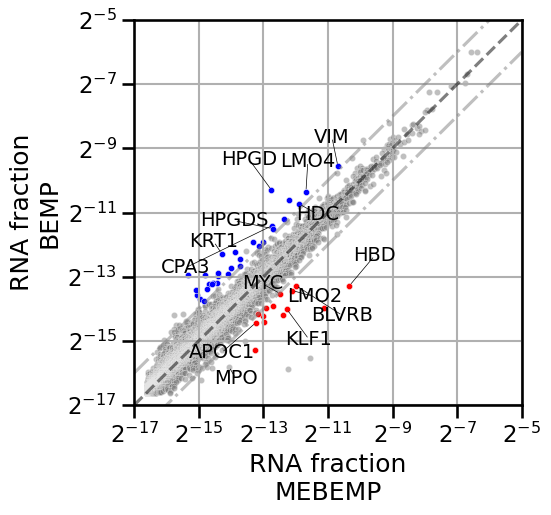

In [19]:
mebemp_bemp_de_sig, mebemp_bemp_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                                                obs1=mebemp_cells, obs2=bemp_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)
                                         

genes_to_show = ["HPGD","KRT1", "LMO4","CPA3", "HPGDS",
                 "HDC","VIM","APOC1","MYC","MPO","BLVRB","LMO2","KLF1"]

utils.plot_de_graph(mebemp_bemp_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-5), xlabel="RNA fraction\nMEBEMP", ylabel="RNA fraction\nBEMP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB"]),
                    genes_to_show=genes_to_show,
                    txt_fix_dict={"LMO4":[-0.5,0],"VIM":[0,0.5],"CPA3":[-2,-1],"HPGDS":[-0.5,0],"HBD":[0.1,0],"LMO2":[0,-0.5],"APOC1":[0.2,0.2],"BLVRB":[2,0],"APOC1":[-0.5,0]},
                    output_path=output_path, file_name= "mebemp_vs_bemp_de_graph", axis_formatter=rna_fraction_formatter)

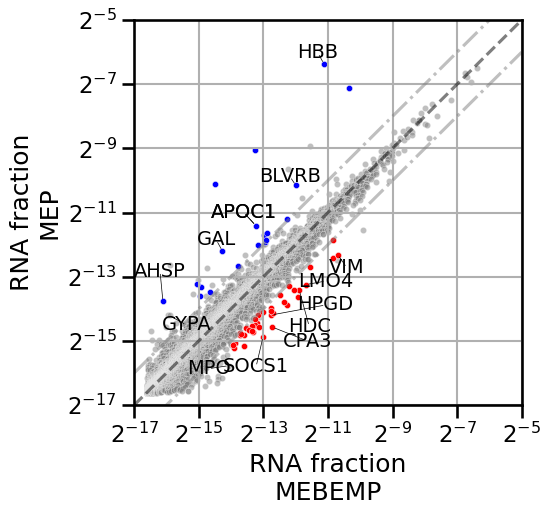

In [ ]:
mebemp_mep_de_sig, mebemp_mep_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=mebemp_cells, obs2=mep_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)


genes_to_show = ["HBB","AHSP","GAL","APOC1","APOC1","BLVRB","GYPA",
                 "HDC","LMO4","VIM","MPO","CPA3","HPGD"]

utils.plot_de_graph(mebemp_mep_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-5), xlabel="RNA fraction\nMEBEMP", ylabel="RNA fraction\nMEP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB"]),
                    genes_to_show=genes_to_show, txt_fix_dict={"HPGD":[1,0],"CPA3":[1,0.5],"HDC":[0,-0.2],"LMO4":[0, -0.2],"MPO":[-1,0]},
                    output_path=output_path, file_name= "mebemp_vs_mep_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

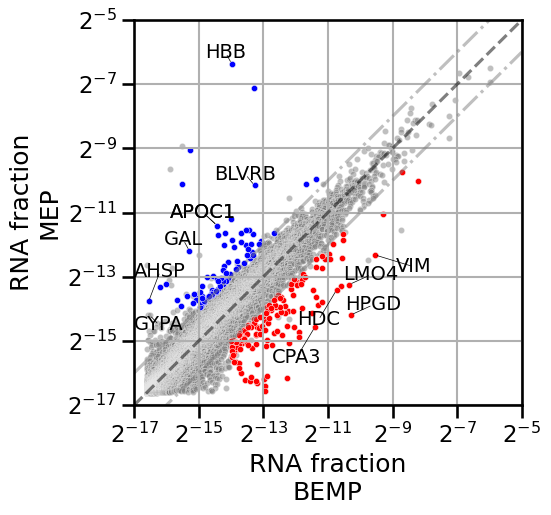

In [21]:
bemp_mep_de_sig, bemp_mep_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                                          obs1=bemp_cells, obs2=mep_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)


genes_to_show = ["HBB","AHSP","GAL","APOC1","APOC1","BLVRB","GYPA",
                 "HDC","LMO4","VIM","CPA3","HPGD"]

utils.plot_de_graph(bemp_mep_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-5), xlabel="RNA fraction\nBEMP", ylabel="RNA fraction\nMEP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB"]),
                    genes_to_show=genes_to_show,  txt_fix_dict={"VIM":[1,0],},
                    output_path=output_path, file_name= "bemp_vs_mep_de_graph",
                    axis_formatter=rna_fraction_formatter
)

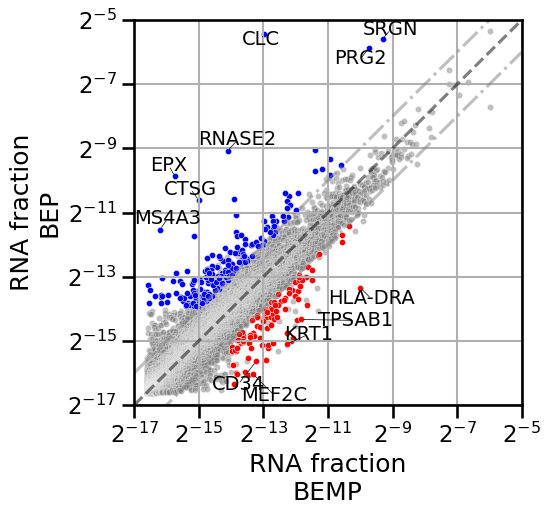

In [22]:
bemp_bep_de_sig, bemp_bep_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=bemp_cells, obs2=bep_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(bemp_bep_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-5), xlabel="RNA fraction\nBEMP", ylabel="RNA fraction\nBEP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB","RNASE2", "HLA-DRA"]),
                    genes_to_show=['CLC', 'EPX', 'RNASE2', 'MS4A3', 'CTSG', 'PRG2', 'SRGN',
                                    "HLA-DRA","KRT1","TPSAB1","CD34","MEF2C",], 
                    txt_fix_dict={"TPSAB1":[1,0.5],},
                    output_path=output_path, file_name= "bemp_vs_bep_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

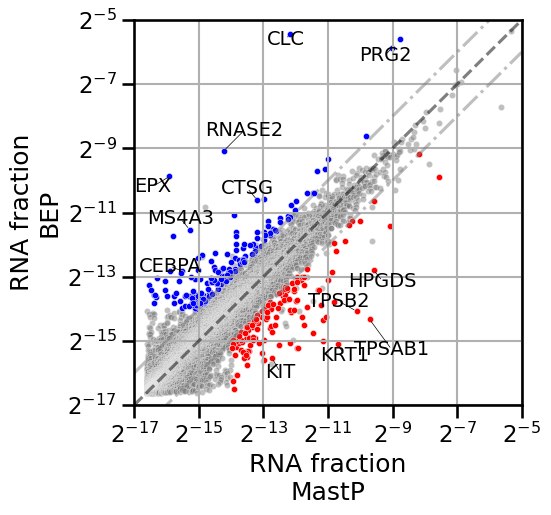

In [23]:
mastp_bep_de_sig, mastp_bep_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=mastp_cells, obs2=bep_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(mastp_bep_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-5), xlabel="RNA fraction\nMastP", ylabel="RNA fraction\nBEP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB","RNASE2"]),
                    genes_to_show=['CLC', 'EPX', 'RNASE2',  'MS4A3', 'PRG2', 'CEBPA',"CTSG",
                                    'TPSB2', 'KRT1', 'TPSAB1',"HPGDS","KIT",
                                    ], 
                    output_path=output_path, file_name= "mastp_vs_bep_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

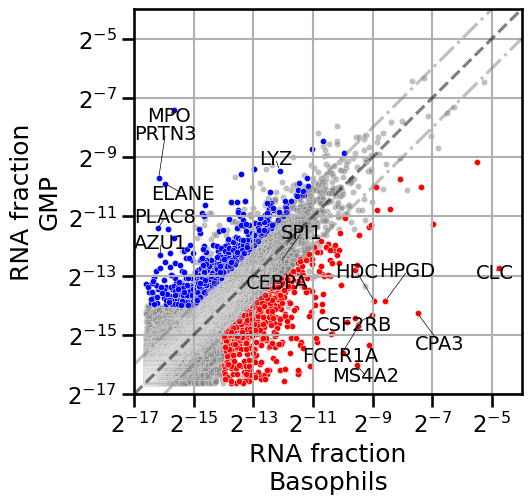

In [24]:
basophils_gmp_de_sign, basophils_gmp_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=basophils_cells, obs2=gmp_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(basophils_gmp_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="RNA fraction\nBasophils", ylabel="RNA fraction\nGMP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB","RNASE2"]),
                    genes_to_show=["MPO","PRTN3","ELANE","PLAC8","AZU1",
                                    "CLC","CPA3","MS4A2","FCER1A","CSF2RB","HPGD","HDC",
                                    "SPI1","CEBPA","LYZ",
                                    ], 
                    txt_fix_dict={"PRTN3":[0,0.5],"CEBPA":[-0.5,0],},
                    output_path=output_path, file_name= "basophils_vs_gmp_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

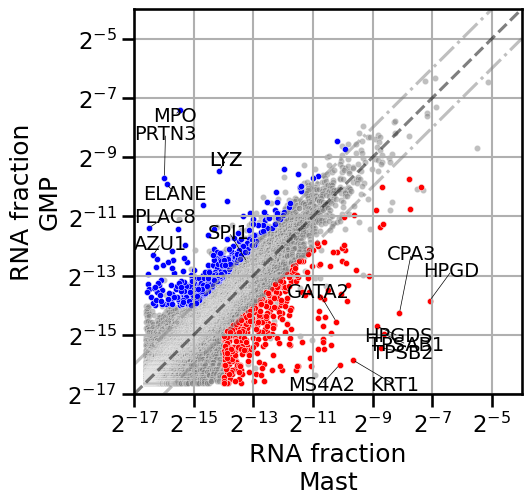

In [25]:
mast_gmp_de_sign, mast_gmp_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=mast_cells, obs2=gmp_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(mast_gmp_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="RNA fraction\nMast", ylabel="RNA fraction\nGMP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB","RNASE2"]),
                    genes_to_show=["MPO","PRTN3","ELANE","PLAC8","AZU1","LYZ",
                                    "GATA2","HPGDS","MS4A2","CPA3","KRT1","TPSAB1","TPSB2","HPGD",
                                    "SPI1","LYZ",
                                    ], 
                    txt_fix_dict={"PRTN3":[0,0.5],"CPA3":[1,1],"TPSB2":[0,-0.5],"KRT1":[2,0]},
                    output_path=output_path, file_name= "mast_vs_gmp_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

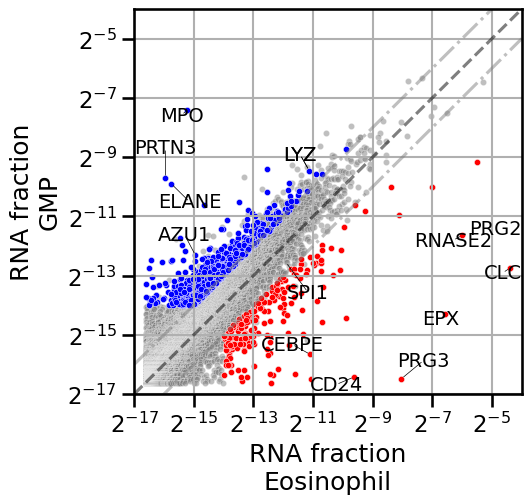

In [26]:
eosi_gmp_de_sign, eosi_gmp_de_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=eosinophil_cells, obs2=gmp_cells, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(eosi_gmp_de_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="RNA fraction\nEosinophil", ylabel="RNA fraction\nGMP",
                    min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].difference(["HBB","RNASE2"]),
                    genes_to_show=["MPO","PRTN3","ELANE","AZU1","LYZ",
                                    "CLC","PRG2","PRG3","EPX","CD24","RNASE2","CEBPE",
                                    "SPI1","LYZ",
                                    ], 
                    txt_fix_dict={},
                    output_path=output_path, file_name= "eosinophil_vs_gmp_de_graph",
                    axis_formatter=rna_fraction_formatter
                    )

## Figure 5F-J, 6SE-G (without 5H)

In [15]:
cells_with_clones_c = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.condition == "III")
top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = cell_types_by_clones.GMP + top_level_cell_types_by_clones.Neutrophils + top_level_cell_types_by_clones.Monocyte
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
terminal_bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[mature_bemp_cell_types].any(axis=1)].index
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]

# bemp_clones.loc[bemp_clones.index,"Mast"] = cell_types_by_clones.loc[bemp_clones.index, "Mast"].astype(int)
# bemp_clones.loc[bemp_clones.index,"MastP"] = cell_types_by_clones.loc[bemp_clones.index, "MastP"].astype(int)

only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types + ["MEBEMP"]].sum(axis=1)][mature_bemp_cell_types]
bemp_ery_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["Ery"]]
bemp_mep_clones = bemp_clones[(bemp_clones.MEP !=0) &(bemp_clones.Ery == 0)][mature_bemp_cell_types + ["MEP"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]

/tmp/ipykernel_1918920/4110422425.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_1918920/4110422425.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


In [16]:
print("Number of BEMP clones %d" % bemp_clones.shape[0])
print("Number of only BEMP clones %d (%.2f)" % (only_bemp_clones.shape[0], only_bemp_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-Ery clones %d (%.2f)" % (bemp_ery_clones.shape[0], bemp_ery_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-GMP clones %d (%.2f)" % (bemp_gmp_lineage_clones.shape[0], bemp_gmp_lineage_clones.shape[0] / bemp_clones.shape[0] * 100))

Number of BEMP clones 273
Number of only BEMP clones 188 (68.86)
Number of BEMP-Ery clones 71 (26.01)
Number of BEMP-GMP clones 20 (7.33)


In [134]:
clones_info_dict, total_clones = get_clones_info(only_bemp_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))

Eosinophil 14
Basophils 41
Mast 36
Eosinophil_Basophils 38
Mast_Basophils 37
Eosinophil_Mast 0
Eosinophil_Mast_Basophils 15


Eosinophil


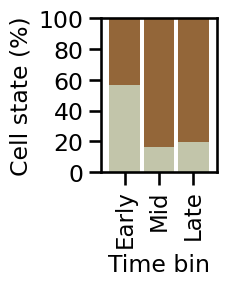

Basophils


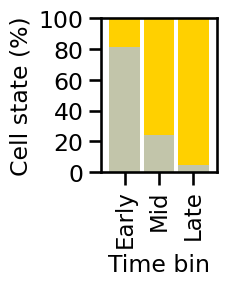

Mast


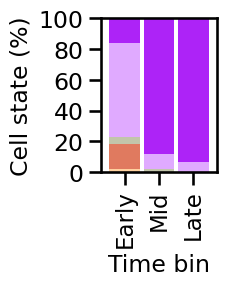

Eosinophil_Basophils


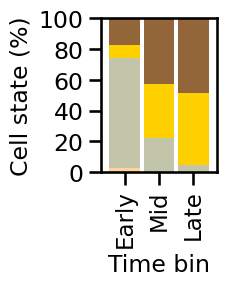

Mast_Basophils


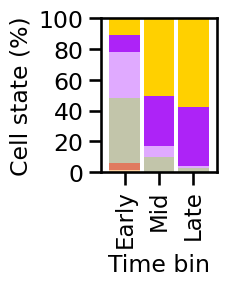

Eosinophil_Mast_Basophils


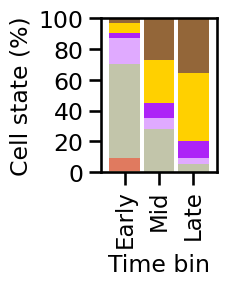

In [135]:
plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP", "MastP","Mast","Basophils","Eosinophil"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_III_only_bemp_clones")

In [136]:
3+1+30+3+10+1

48

In [137]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_ery_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


Eosinophil 0
Basophils 0
Mast 13
Ery 1
Eosinophil_Basophils 2
Eosinophil_Mast 0
Eosinophil_Ery 3
Basophils_Mast 4
Basophils_Ery 1
Mast_Ery 30
Eosinophil_Basophils_Mast 3
Eosinophil_Basophils_Ery 3
Eosinophil_Mast_Ery 0
Basophils_Mast_Ery 10
Eosinophil_Basophils_Mast_Ery 1


Mast


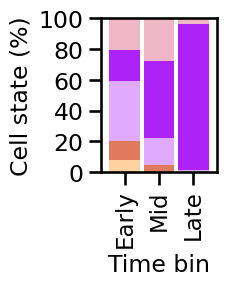

Ery


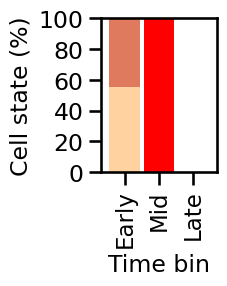

Eosinophil_Basophils


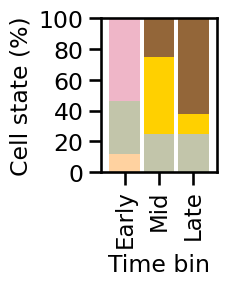

Eosinophil_Ery


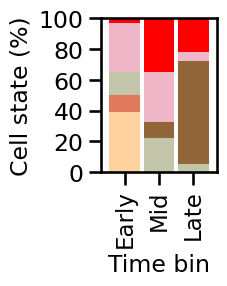

Basophils_Mast


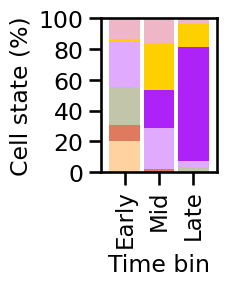

Basophils_Ery


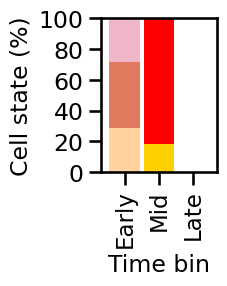

Mast_Ery


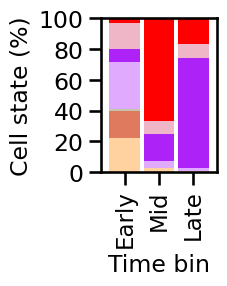

Eosinophil_Basophils_Mast


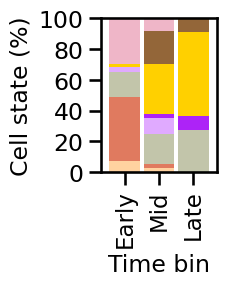

Eosinophil_Basophils_Ery


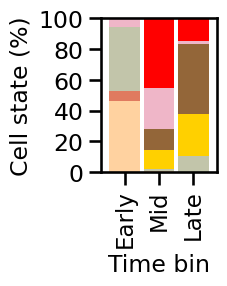

Basophils_Mast_Ery


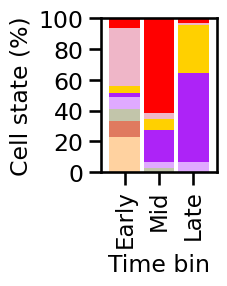

Eosinophil_Basophils_Mast_Ery


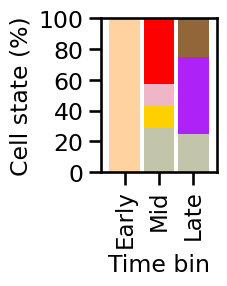

In [138]:
plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP", "MastP","Mast","Basophils","Eosinophil","MEP","Ery"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_III_bemp_ery_clones")

In [4]:
4+6+1+1+3+2+2

19

In [140]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_gmp_lineage_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


Eosinophil 0
Basophils 0
Mast 0
GMP 1
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_GMP 6
Basophils_Mast 0
Basophils_GMP 2
Mast_GMP 2
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_GMP 4
Eosinophil_Mast_GMP 1
Basophils_Mast_GMP 1
Eosinophil_Basophils_Mast_GMP 3


GMP


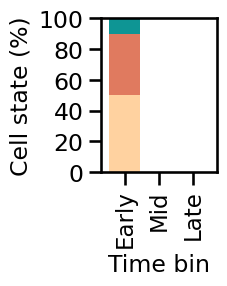

Eosinophil_GMP


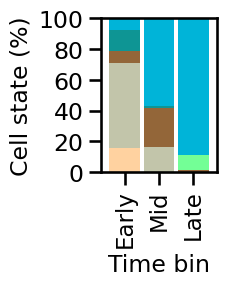

Basophils_GMP


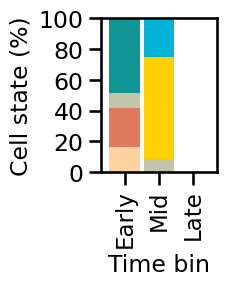

Mast_GMP


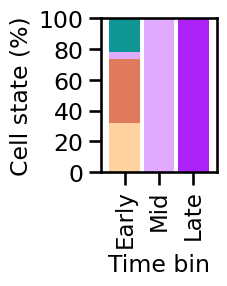

Eosinophil_Basophils_GMP


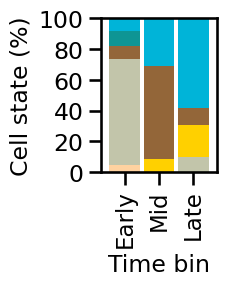

Eosinophil_Mast_GMP


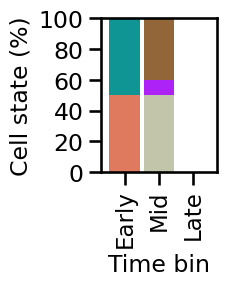

Basophils_Mast_GMP


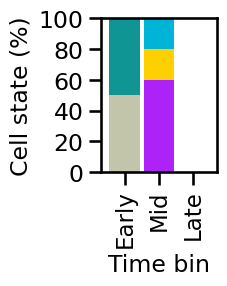

Eosinophil_Basophils_Mast_GMP


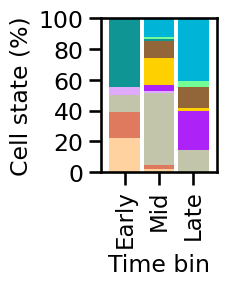

In [141]:
plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP","MastP","Mast","Basophils","Eosinophil","GMP", "Monocyte", "Neutrophils"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_III_bemp_gmp_clones")

In [233]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_mep_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


Eosinophil 0
Basophils 0
Mast 0
MEP 0
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_MEP 0
Basophils_Mast 0
Basophils_MEP 0
Mast_MEP 13
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_MEP 2
Eosinophil_Mast_MEP 0
Basophils_Mast_MEP 4
Eosinophil_Basophils_Mast_MEP 3


## Figure 5H

In [96]:
clones_top_level_cell_type_df = cells_with_clones.obs.groupby(["clone_exp_id","top_level_cell_type"]).size().unstack(fill_value=0)
clones_with_eosi_baso = clones_top_level_cell_type_df[["Basophils", "Eosinophil"]].sum(axis=1)
clones_with_eosi_baso = clones_with_eosi_baso[clones_with_eosi_baso >= 4].index

clones_with_eosi_baso_cells = clones_top_level_cell_type_df.loc[clones_with_eosi_baso, ["Mast","Basophils","Eosinophil"]]
clones_with_eosi_baso_cells_frac = clones_with_eosi_baso_cells.div(clones_with_eosi_baso_cells.sum(axis=1),axis=0)

only_clones_with_eosi_baso_cells = clones_top_level_cell_type_df.loc[clones_with_eosi_baso, ["Basophils","Eosinophil"]] 
only_clones_with_eosi_baso_cells_frac = only_clones_with_eosi_baso_cells.div(only_clones_with_eosi_baso_cells.sum(axis=1),axis=0)
only_clones_with_eosi_baso_cells_ratio = (only_clones_with_eosi_baso_cells.Basophils + 0.1) / (only_clones_with_eosi_baso_cells.Eosinophil + 0.1)

no_mast_clones = clones_with_eosi_baso_cells[clones_with_eosi_baso_cells_frac.Mast == 0].index
few_mast_clones = clones_with_eosi_baso_cells[(clones_with_eosi_baso_cells_frac.Mast > 0) & (clones_with_eosi_baso_cells_frac.Mast <=0.5)].index
many_mast_clones = clones_with_eosi_baso_cells[(clones_with_eosi_baso_cells_frac.Mast > 0.5)].index

cont_table = pd.DataFrame(0, index=["No mast", "Few mast", "Many mast"], columns=["Basophils","Eosinophil"])
cont_table.loc["No mast"] = only_clones_with_eosi_baso_cells.loc[no_mast_clones].sum(axis=0)
cont_table.loc["Few mast"] = only_clones_with_eosi_baso_cells.loc[few_mast_clones].sum(axis=0)
cont_table.loc["Many mast"] = only_clones_with_eosi_baso_cells.loc[many_mast_clones].sum(axis=0)

/tmp/ipykernel_943489/90622427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clones_top_level_cell_type_df = cells_with_clones.obs.groupby(["clone_exp_id","top_level_cell_type"]).size().unstack(fill_value=0)


In [97]:
chi2, p, dof, expected = chi2_contingency(cont_table)
print(p)

4.509035470939752e-100


In [98]:
pairs = list(itertools.combinations(cont_table.index.tolist(), 2))

results = []
for g1, g2 in pairs:
    # 2x2 table for this pair
    sub = cont_table.loc[[g1, g2], ["Basophils", "Eosinophil"]].copy()

    # Chi-square test
    chi2, p_chi, dof, expected = chi2_contingency(sub.values)

    # Effect size (Cramér's V for 2x2)
    n = sub.to_numpy().sum()
    cramer_v = np.sqrt(chi2 / n) if n > 0 else np.nan

    # Fisher exact (robust when expected < 5); also gives odds ratio
    # SciPy uses (a,b; c,d) as [[row1 col1, row1 col2], [row2 col1, row2 col2]]
    # By default, 'two-sided' p-value.
    try:
        or_fisher, p_fisher = fisher_exact(sub.values, alternative='two-sided')
    except Exception:
        or_fisher, p_fisher = np.nan, np.nan

    # Standardized residuals for directionality
    std_resid = (sub.values - expected) / np.sqrt(expected)
    std_resid_df = pd.DataFrame(std_resid, index=sub.index, columns=sub.columns)

    results.append({
        "group1": g1,
        "group2": g2,
        "chi2": chi2,
        "p_chi": p_chi,
        "cramers_v": cramer_v,
        "fisher_or": or_fisher,
        "p_fisher": p_fisher,
        "expected_min": expected.min(),
        "sub_table": sub,
        "std_resid": std_resid_df
    })

# Collect p-values and correct (use chi-square by default; switch to Fisher if many small expecteds)
pvals = [r["p_chi"] for r in results]
rejected, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
for r, pa, rej in zip(results, p_adj, rejected):
    r["p_chi_adj"] = pa
    r["significant_chi"] = bool(rej)

# Optional: also adjust Fisher p-values
pvals_f = [r["p_fisher"] for r in results]
if not any(np.isnan(pvals_f)):
    rejected_f, p_adj_f, _, _ = multipletests(pvals_f, method="fdr_bh")
    for r, pa, rej in zip(results, p_adj_f, rejected_f):
        r["p_fisher_adj"] = pa
        r["significant_fisher"] = bool(rej)

# Neat summary
summary_rows = []
for r in results:
    summary_rows.append({
        "group1": r["group1"],
        "group2": r["group2"],
        "chi2": r["chi2"],
        "p_chi_adj": r["p_chi_adj"],
        "cramers_v": r["cramers_v"],
        "p_fisher_adj": r.get("p_fisher_adj", np.nan),
        "fisher_or": r["fisher_or"],
        "expected_min": r["expected_min"]
    })
pairwise_summary = pd.DataFrame(summary_rows).sort_values("p_chi_adj")
print(pairwise_summary)


     group1     group2        chi2     p_chi_adj  cramers_v  p_fisher_adj  \
0   No mast   Few mast  353.011851  2.807990e-78   0.272327  2.415982e-79   
1   No mast  Many mast  136.379638  2.472101e-31   0.185251  6.277319e-34   
2  Few mast  Many mast   21.865151  2.924979e-06   0.147427  1.548318e-07   

   fisher_or  expected_min  
0   0.230328    398.682353  
1   0.041593     43.457474  
2   0.180583     27.554672  


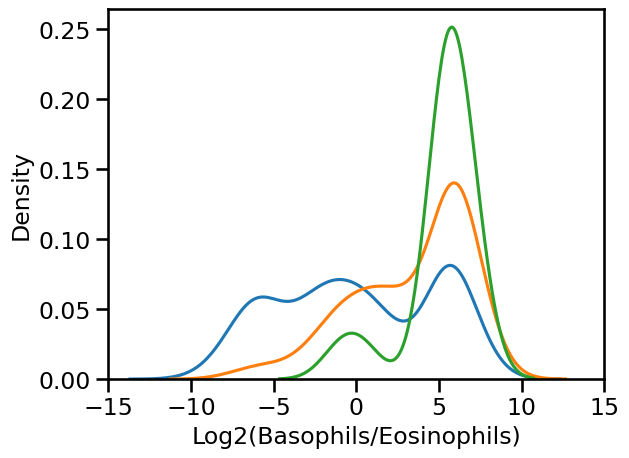

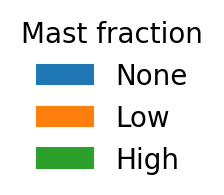

array([9.48274872e-07, 2.52056148e-05, 4.51515503e-02])

In [ ]:
sb.kdeplot(np.log2(only_clones_with_eosi_baso_cells_ratio[no_mast_clones]), label="No Mast", fill=False, alpha=1, common_norm=True)
sb.kdeplot(np.log2(only_clones_with_eosi_baso_cells_ratio[few_mast_clones]), label="Few Mast", fill=False, alpha=1, common_norm=True)
sb.kdeplot(np.log2(only_clones_with_eosi_baso_cells_ratio[many_mast_clones]), label="Many Mast", fill=False, alpha=1, common_norm=True)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=17, frameon=False, title="Mast fraction", title_fontsize=17).remove()
plt.xlabel("Log2(Basophils/Eosinophils)", fontsize=17)
plt.ylabel("Density", fontsize=17)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlim(-15,15)
plt.savefig(os.path.join(output_path, "5H_bemp_eosi_baso_clones_mast_fraction_kde.pdf"), dpi=300, bbox_inches='tight')
plt.show()

utils.plot_generic_dict_of_colors(
    {
        "None": "C0",
        "Low": "C1",
        "High": "C2",
    }, title="Mast fraction"
)

utils.plot_generic_dict_of_colors(
    {
        "None": "C0",
        "Low": "C1",
        "High": "C2",
    }, title="Mast fraction",
    output_path=os.path.join(output_path, "5H_legend.pdf")
)



from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests

pairs = list(itertools.combinations([only_clones_with_eosi_baso_cells_ratio[no_mast_clones], 
                                     only_clones_with_eosi_baso_cells_ratio[few_mast_clones],
                                     only_clones_with_eosi_baso_cells_ratio[many_mast_clones]], 2))

pvals = []
for pair in pairs:
    stat, pvalue = ks_2samp(pair[0], pair[1])
    pvals.append(pvalue)
    
    
# Apply FDR correction (Benjamini–Hochberg)
rejected, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
p_adj


## Figure 5SE-H, S6A-B

In [12]:
cells_with_clones_c = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.condition == "I")
top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = cell_types_by_clones.GMP + top_level_cell_types_by_clones.Neutrophils + top_level_cell_types_by_clones.Monocyte
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
terminal_bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[mature_bemp_cell_types].any(axis=1)].index
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]


only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types + ["MEBEMP"]].sum(axis=1)][mature_bemp_cell_types]
bemp_ery_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["Ery"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]

/tmp/ipykernel_1918920/3824449042.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_1918920/3824449042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


In [13]:
print("Number of BEMP clones %d" % bemp_clones.shape[0])
print("Number of only BEMP clones %d (%.2f)" % (only_bemp_clones.shape[0], only_bemp_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-Ery clones %d (%.2f)" % (bemp_ery_clones.shape[0], bemp_ery_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-GMP clones %d (%.2f)" % (bemp_gmp_lineage_clones.shape[0], bemp_gmp_lineage_clones.shape[0] / bemp_clones.shape[0] * 100))

Number of BEMP clones 94
Number of only BEMP clones 65 (69.15)
Number of BEMP-Ery clones 27 (28.72)
Number of BEMP-GMP clones 2 (2.13)


Eosinophil 4
Basophils 15
Mast 18
Eosinophil_Basophils 7
Mast_Basophils 10
Eosinophil_Mast 0
Eosinophil_Mast_Basophils 1
Eosinophil


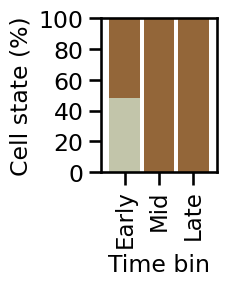

Basophils


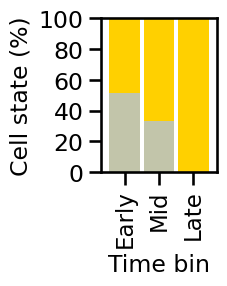

Mast


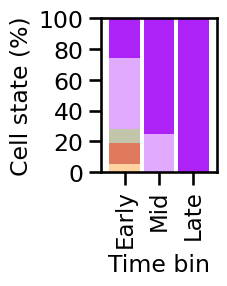

Eosinophil_Basophils


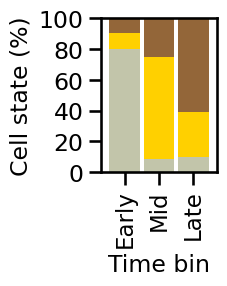

Mast_Basophils


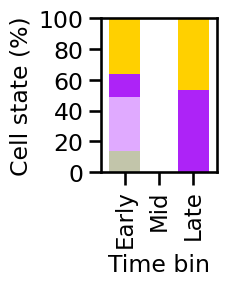

Eosinophil_Mast_Basophils


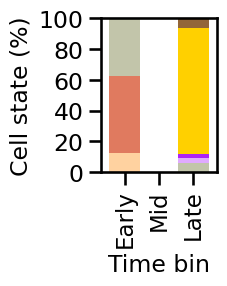

In [14]:
clones_info_dict, total_clones = get_clones_info(only_bemp_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))
	

plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP","MastP","Mast","Basophils","Eosinophil"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_I_only_bemp_clones")

Eosinophil 0
Basophils 0
Mast 2
Ery 2
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_Ery 0
Basophils_Mast 0
Basophils_Ery 1
Mast_Ery 15
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_Ery 0
Eosinophil_Mast_Ery 0
Basophils_Mast_Ery 7
Eosinophil_Basophils_Mast_Ery 0
Mast


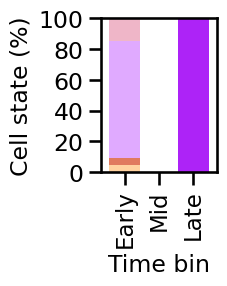

Ery


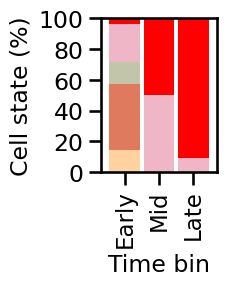

Basophils_Ery


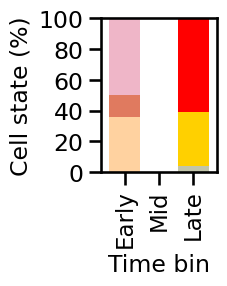

Mast_Ery


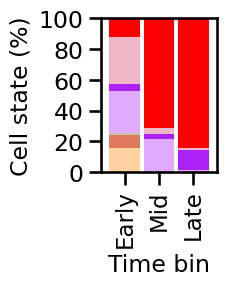

Basophils_Mast_Ery


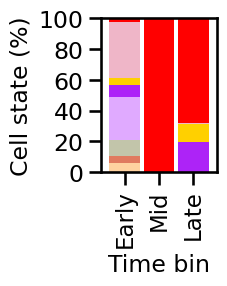

In [146]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_ery_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP", "MastP","Mast","Basophils","Eosinophil","MEP","Ery"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_I_bemp_ery_clones")

In [147]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_gmp_lineage_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


Eosinophil 0
Basophils 0
Mast 0
GMP 0
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_GMP 1
Basophils_Mast 0
Basophils_GMP 0
Mast_GMP 0
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_GMP 0
Eosinophil_Mast_GMP 0
Basophils_Mast_GMP 0
Eosinophil_Basophils_Mast_GMP 1


In [148]:
cells_with_clones_c = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.condition == "II")
top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = cell_types_by_clones.GMP + top_level_cell_types_by_clones.Neutrophils + top_level_cell_types_by_clones.Monocyte
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
terminal_bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[mature_bemp_cell_types].any(axis=1)].index
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]


only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types + ["MEBEMP"]].sum(axis=1)][mature_bemp_cell_types]
bemp_ery_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["Ery"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]


print("Number of BEMP clones %d" % bemp_clones.shape[0])
print("Number of only BEMP clones %d (%.2f)" % (only_bemp_clones.shape[0], only_bemp_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-Ery clones %d (%.2f)" % (bemp_ery_clones.shape[0], bemp_ery_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-GMP clones %d (%.2f)" % (bemp_gmp_lineage_clones.shape[0], bemp_gmp_lineage_clones.shape[0] / bemp_clones.shape[0] * 100))

Number of BEMP clones 178
Number of only BEMP clones 148 (83.15)
Number of BEMP-Ery clones 26 (14.61)
Number of BEMP-GMP clones 4 (2.25)


/tmp/ipykernel_973240/1846747391.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_973240/1846747391.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


Eosinophil 14
Basophils 32
Mast 25
Eosinophil_Basophils 39
Mast_Basophils 30
Eosinophil_Mast 0
Eosinophil_Mast_Basophils 7
Eosinophil


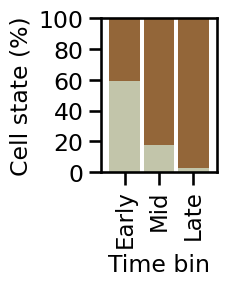

Basophils


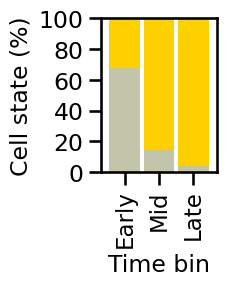

Mast


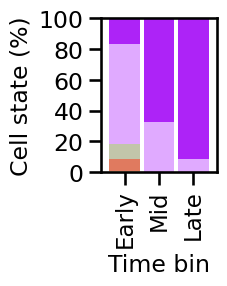

Eosinophil_Basophils


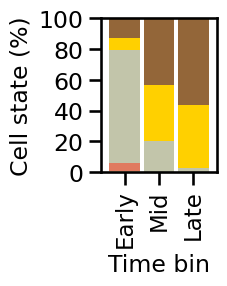

Mast_Basophils


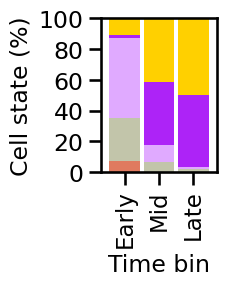

Eosinophil_Mast_Basophils


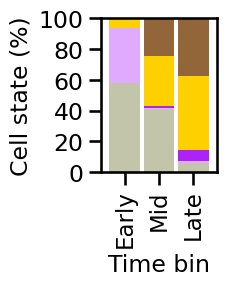

In [149]:
clones_info_dict, total_clones = get_clones_info(only_bemp_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))
	

plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP","MastP","Mast","Basophils","Eosinophil"] , cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_II_only_bemp_clones")

Eosinophil 0
Basophils 0
Mast 5
Ery 0
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_Ery 0
Basophils_Mast 2
Basophils_Ery 1
Mast_Ery 11
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_Ery 1
Eosinophil_Mast_Ery 0
Basophils_Mast_Ery 6
Eosinophil_Basophils_Mast_Ery 0
Mast


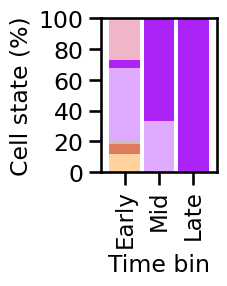

Basophils_Mast


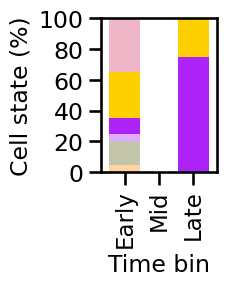

Basophils_Ery


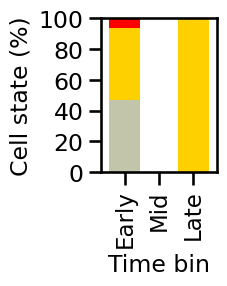

Mast_Ery


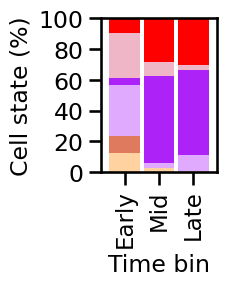

Eosinophil_Basophils_Ery


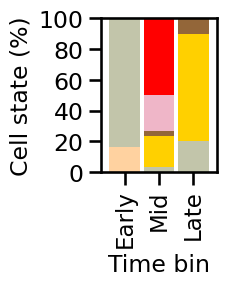

Basophils_Mast_Ery


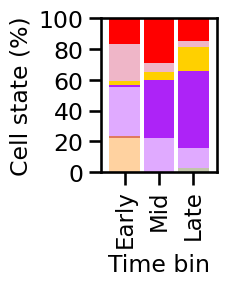

In [150]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_ery_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP", "MastP","Mast","Basophils","Eosinophil","MEP","Ery"] , cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_II_bemp_ery_clones")

In [215]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_gmp_lineage_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))


Eosinophil 0
Basophils 0
Mast 0
GMP 0
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_GMP 0
Basophils_Mast 0
Basophils_GMP 0
Mast_GMP 0
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_GMP 3
Eosinophil_Mast_GMP 0
Basophils_Mast_GMP 0
Eosinophil_Basophils_Mast_GMP 1


In [151]:
cells_with_clones_c = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.condition == "IV")
top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = top_level_cell_types_by_clones.Neutrophils 
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
terminal_bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[mature_bemp_cell_types].any(axis=1)].index
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]


only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types + ["MEBEMP"]].sum(axis=1)][mature_bemp_cell_types]
bemp_ery_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["Ery"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]


print("Number of BEMP clones %d" % bemp_clones.shape[0])
print("Number of only BEMP clones %d (%.2f)" % (only_bemp_clones.shape[0], only_bemp_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-Ery clones %d (%.2f)" % (bemp_ery_clones.shape[0], bemp_ery_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-GMP clones %d (%.2f)" % (bemp_gmp_lineage_clones.shape[0], bemp_gmp_lineage_clones.shape[0] / bemp_clones.shape[0] * 100))

Number of BEMP clones 77
Number of only BEMP clones 65 (84.42)
Number of BEMP-Ery clones 11 (14.29)
Number of BEMP-GMP clones 1 (1.30)


/tmp/ipykernel_973240/1263717505.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_973240/1263717505.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


Eosinophil 12
Basophils 18
Mast 0
Eosinophil_Basophils 32
Mast_Basophils 1
Eosinophil_Mast 0
Eosinophil_Mast_Basophils 2
Eosinophil


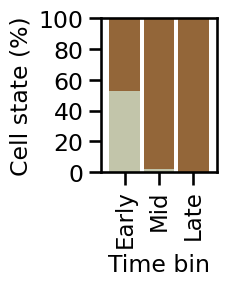

Basophils


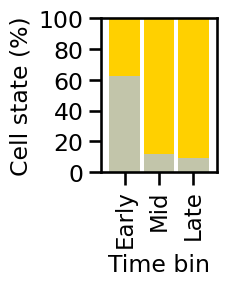

Eosinophil_Basophils


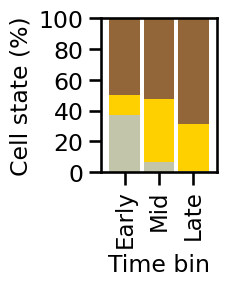

Mast_Basophils


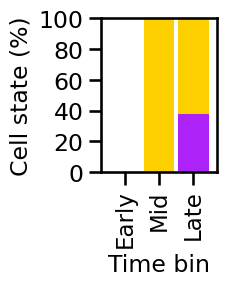

Eosinophil_Mast_Basophils


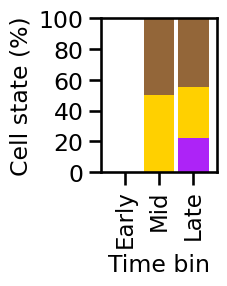

In [152]:
clones_info_dict, total_clones = get_clones_info(only_bemp_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))
	

plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP","MastP","Mast","Basophils","Eosinophil"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_IV_only_bemp_clones")

Eosinophil 0
Basophils 0
Mast 0
Ery 0
Eosinophil_Basophils 1
Eosinophil_Mast 0
Eosinophil_Ery 0
Basophils_Mast 0
Basophils_Ery 1
Mast_Ery 2
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_Ery 0
Eosinophil_Mast_Ery 0
Basophils_Mast_Ery 6
Eosinophil_Basophils_Mast_Ery 1
Eosinophil_Basophils


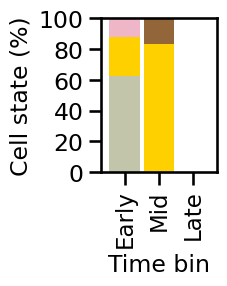

Basophils_Ery


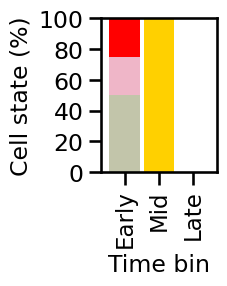

Mast_Ery


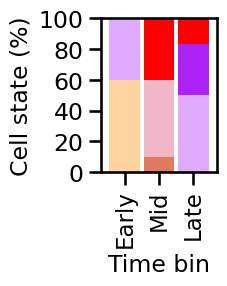

Basophils_Mast_Ery


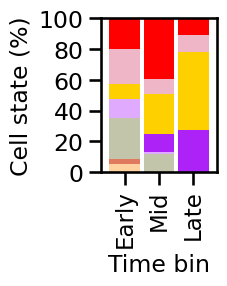

Eosinophil_Basophils_Mast_Ery


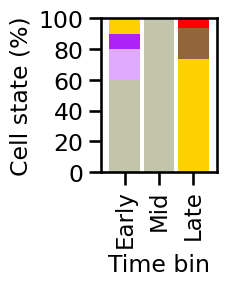

In [154]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_ery_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))

plot_cells_distribution(clones_info_dict, types = ["MEBEMP","BEMP","BEP", "MastP","Mast","Basophils","Eosinophil","MEP","Ery"], cells_with_clones=cells_with_clones, cell_type_colors=cell_type_colors,
                        output_folder = output_path, filename_prefix="media_IV_bemp_ery_clones")

In [223]:
clones_info_dict, total_clones = get_clones_info_automatic(bemp_gmp_lineage_clones)

for i in clones_info_dict:
    print(i, len(clones_info_dict[i]))

Eosinophil 0
Basophils 0
Mast 0
GMP 0
Eosinophil_Basophils 0
Eosinophil_Mast 0
Eosinophil_GMP 0
Basophils_Mast 0
Basophils_GMP 0
Mast_GMP 0
Eosinophil_Basophils_Mast 0
Eosinophil_Basophils_GMP 0
Eosinophil_Mast_GMP 0
Basophils_Mast_GMP 0
Eosinophil_Basophils_Mast_GMP 1


## Figure S6C-D

In [28]:
cells_with_clones_c = cells_with_clones.copy()
top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = cell_types_by_clones.GMP + top_level_cell_types_by_clones.Neutrophils + top_level_cell_types_by_clones.Monocyte
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]

only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types + ["MEBEMP"]].sum(axis=1)][mature_bemp_cell_types]
bemp_mep_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["Ery"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]

/tmp/ipykernel_2116655/2128031111.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_2116655/2128031111.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones_c.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


In [29]:
clones_info_dict, total_clones = get_clones_info(only_bemp_clones)
baso_clones = clones_info_dict["Basophils"]
eosi_baso_clones = clones_info_dict["Eosinophil_Basophils"]
baso_mast_clones = clones_info_dict["Mast_Basophils"]

In [30]:
bep_baso_mast = cells_ad.obs.clone_exp_id.isin(baso_mast_clones) & (cells_ad.obs.cell_type == "BEP")
bep_baso_mast = bep_baso_mast[bep_baso_mast].index
bep_baso_eosi = cells_ad.obs.clone_exp_id.isin(eosi_baso_clones) & (cells_ad.obs.cell_type == "BEP")
bep_baso_eosi = bep_baso_eosi[bep_baso_eosi].index
bep_baso_only = cells_ad.obs.clone_exp_id.isin(baso_clones) & (cells_ad.obs.cell_type == "BEP")
bep_baso_only = bep_baso_only[bep_baso_only].index

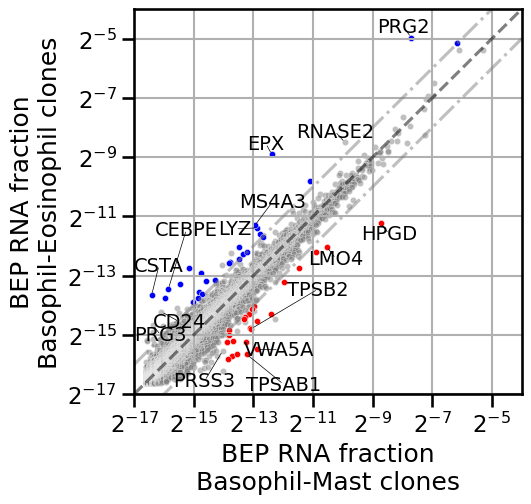

In [42]:
bep_baso_mast_vs_bep_baso_eosi_sign, bep_baso_mast_vs_bep_baso_eosi_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=bep_baso_mast, obs2=bep_baso_eosi, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(bep_baso_mast_vs_bep_baso_eosi_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="BEP RNA fraction\nBasophil-Mast clones", ylabel="BEP RNA fraction\nBasophil-Eosinophil clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene],
                  genes_to_show = ["EPX", "PRG2", "CSTA", "CEBPE", "CD24", "PRG3","MS4A3","LYZ","RNASE2",
                                   'TPSAB1', 'HPGD', 'VWA5A', 'PRSS3', 'TPSB2',"LMO4",],
                  txt_fix_dict={"CEBPE":[0,1],"TPSB2":[1.5,1],"VWA5A":[0,1],"TPSAB1":[0.5,0]},
                  output_path=output_path, file_name= "S6D_bep_in_baso_mast_clones_vs_baso_eosi_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
)

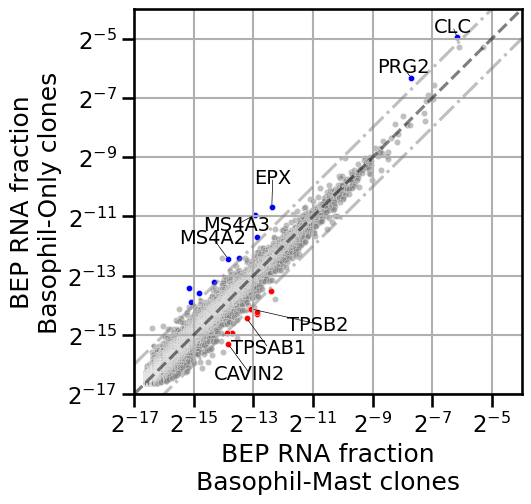

In [43]:
bep_baso_mast_vs_bep_baso_only_sign, bep_baso_mast_vs_bep_baso_only_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=bep_baso_mast, obs2=bep_baso_only, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(bep_baso_mast_vs_bep_baso_only_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="BEP RNA fraction\nBasophil-Mast clones", ylabel="BEP RNA fraction\nBasophil-Only clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene].union(["ALB"]),
                  genes_to_show = ["CLC","PRG2","EPX","MS4A3","MS4A2","TPSB2","TPSAB1","CAVIN2"],
                  txt_fix_dict={"TPSB2":[1.5,0.5],},
                  output_path=output_path, file_name= "S6D_bep_in_baso_mast_clones_vs_baso_only_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
                )

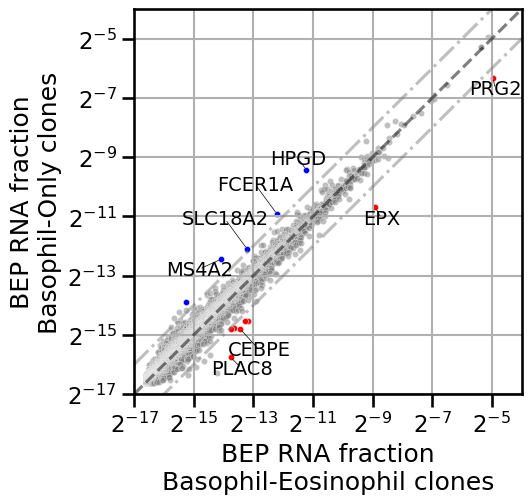

In [44]:
bep_baso_eosi_vs_bep_baso_only_sign, bep_baso_eosi_vs_bep_baso_only_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=bep_baso_eosi, obs2=bep_baso_only, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)
utils.plot_de_graph(bep_baso_eosi_vs_bep_baso_only_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="BEP RNA fraction\nBasophil-Eosinophil clones", ylabel="BEP RNA fraction\nBasophil-Only clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene],
                  genes_to_show = ["PRG2","EPX","CEBPE","PLAC8","HPGD","FCER1A","SLC18A2","MS4A2"],
                  output_path=output_path, file_name= "S6D_bep_in_baso_eosi_clones_vs_baso_only_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
                  )

In [45]:
baso_baso_mast = cells_ad.obs.clone_exp_id.isin(baso_mast_clones) & (cells_ad.obs.cell_type == "Basophils")
baso_baso_mast = baso_baso_mast[baso_baso_mast].index
baso_baso_eosi = cells_ad.obs.clone_exp_id.isin(eosi_baso_clones) & (cells_ad.obs.cell_type == "Basophils")
baso_baso_eosi = baso_baso_eosi[baso_baso_eosi].index
baso_baso_only = cells_ad.obs.clone_exp_id.isin(baso_clones) & (cells_ad.obs.cell_type == "Basophils")
baso_baso_only = baso_baso_only[baso_baso_only].index

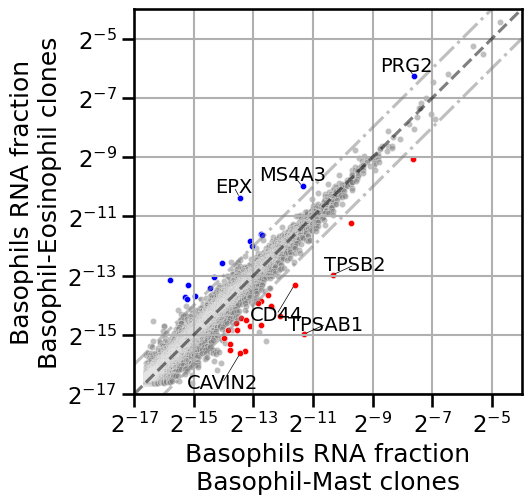

In [47]:
baso_baso_mast_vs_baso_baso_eosi_sign, baso_baso_mast_vs_baso_baso_eosi_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=baso_baso_mast, obs2=baso_baso_eosi, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)

utils.plot_de_graph(baso_baso_mast_vs_baso_baso_eosi_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="Basophils RNA fraction\nBasophil-Mast clones", ylabel="Basophils RNA fraction\nBasophil-Eosinophil clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene],
                  genes_to_show = ["PRG2","EPX","MS4A3","TPSB2","CD44","TPSAB1","CAVIN2"],
                  output_path=output_path, file_name= "S6C_baso_in_baso_mast_clones_vs_baso_eosi_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
                  )

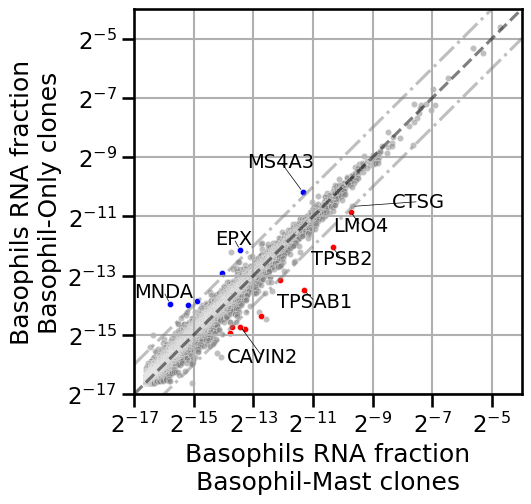

In [48]:
baso_baso_mast_vs_baso_baso_only_sign, baso_baso_mast_vs_baso_baso_only_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=baso_baso_mast, obs2=baso_baso_only, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)
utils.plot_de_graph(baso_baso_mast_vs_baso_baso_only_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=1, xylim=(-17,-4), xlabel="Basophils RNA fraction\nBasophil-Mast clones", ylabel="Basophils RNA fraction\nBasophil-Only clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene],
                  genes_to_show = ["MS4A3","LMO4","EPX","CTSG","TPSB2","TPSAB1","CAVIN2"],
                  txt_fix_dict={"CTSG":[1.5,0.5],},
                  output_path=output_path, file_name= "S6C_baso_in_baso_mast_clones_vs_baso_only_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
                )

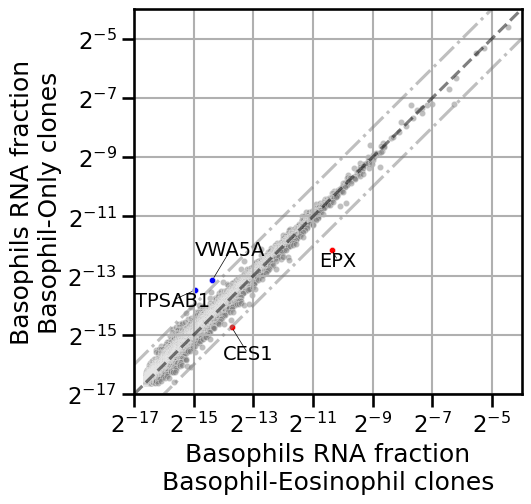

In [49]:
baso_baso_eosi_vs_baso_baso_only_sign, baso_baso_eosi_vs_baso_baso_only_all = utils.calc_diff_expression_genes_cells(cells_anndata=cells_ad, 
                                                 obs1=baso_baso_eosi, obs2=baso_baso_only, diff_thresh=1, pval_thresh=0.05, epsilon=1e-5, calculate_p_val=True)
utils.plot_de_graph(baso_baso_eosi_vs_baso_baso_only_all, min_pval=0.05, min_rlgc_to_plot=1, figsize=(5,5), max_genes_names=10, xylim=(-17,-4), xlabel="Basophils RNA fraction\nBasophil-Eosinophil clones", ylabel="Basophils RNA fraction\nBasophil-Only clones",
                  min_expression = -14, exp_to_plot=-16, genes_to_ignore=cells_ad.var_names[cells_ad.var.lateral_gene],
                  output_path=output_path, file_name= "S6C_baso_in_baso_eosi_clones_vs_baso_only_clones_de_graph",
                    axis_formatter=rna_fraction_formatter
                )

## Figure S5B

In [52]:
bemp_trajectory_cells = mc.ut.slice(cells_ad, obs=cells_ad.obs.cell_type.isin(["BEMP","BEP","MastP","Mast","Basophils","Eosinophil"]))

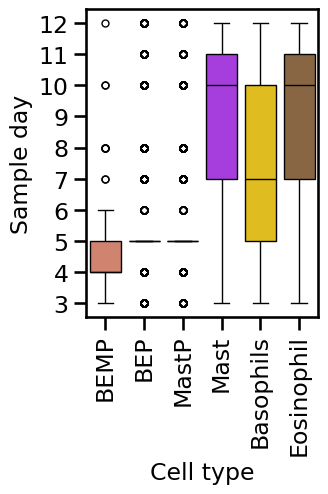

In [53]:
plt.figure(figsize=(3,4))
sb.boxplot(data=bemp_trajectory_cells.obs, x="cell_type", y="sample_day_as_int", order=["BEMP","BEP","MastP","Mast","Basophils","Eosinophil"], palette=cell_type_colors, legend=False, hue="cell_type",
           fliersize=5)
plt.ylabel("Sample day", fontsize=17)
plt.xlabel("Cell type", fontsize=17)
_=plt.xticks(fontsize=17, rotation=90)
_=plt.yticks(range(3,13), fontsize=17)
plt.savefig(os.path.join(output_path, "S5B_bemp_trajectory_cell_types_sample_day_boxplot.pdf"), dpi=300, bbox_inches='tight')
plt.show()

# General data

In [150]:
top_level_cell_types_by_clones = cells_with_clones.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
cell_types_by_clones = cells_with_clones.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()
top_level_cell_types_by_clones.loc[:,"GMP"] = cell_types_by_clones.GMP + top_level_cell_types_by_clones.Neutrophils + top_level_cell_types_by_clones.Monocyte
top_level_cell_types_by_clones.loc[:,"MEP"] = cell_types_by_clones.MEP + top_level_cell_types_by_clones.Ery + top_level_cell_types_by_clones.MK
bemp_cell_types = ["Eosinophil","Basophils","Mast","BEMP","BEP"]
mature_bemp_cell_types = ["Eosinophil","Basophils","Mast"]
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[mature_bemp_cell_types].any(axis=1)]
bemp_clones = top_level_cell_types_by_clones[top_level_cell_types_by_clones[bemp_cell_types].sum(axis=1) >= 4]


only_bemp_clones = bemp_clones[bemp_clones.sum(axis=1) == bemp_clones[bemp_cell_types].sum(axis=1)][mature_bemp_cell_types]
bemp_ery_clones = bemp_clones[bemp_clones.MEP !=0][mature_bemp_cell_types + ["MEP"]]
bemp_gmp_lineage_clones = bemp_clones[(bemp_clones.GMP !=0) ][mature_bemp_cell_types + ["GMP"]]

/tmp/ipykernel_943489/4150290624.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_level_cell_types_by_clones = cells_with_clones.obs.groupby(["clone_exp_id", "top_level_cell_type"]).size().unstack()
/tmp/ipykernel_943489/4150290624.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_types_by_clones = cells_with_clones.obs.groupby(["clone_exp_id", "cell_type"]).size().unstack()


In [1]:
print("Total BEMP cells %d" % cells_with_clones.obs[cells_with_clones.obs.cell_type.isin(["BEMP","BEP","MastP","Mast","Basophils","Eosinophil"])].shape[0])
print("Number of BEMP clones %d" % bemp_clones.shape[0])
print("Number of only BEMP clones %d (%.2f)" % (only_bemp_clones.shape[0], only_bemp_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-Ery clones %d (%.2f)" % (bemp_ery_clones.shape[0], bemp_ery_clones.shape[0] / bemp_clones.shape[0] * 100))
print("Number of BEMP-GMP clones %d (%.2f)" % (bemp_gmp_lineage_clones.shape[0], bemp_gmp_lineage_clones.shape[0] / bemp_clones.shape[0] * 100))

NameError: name 'cells_with_clones' is not defined